In [25]:
import pandas as pd
import numpy as np

features = pd.read_csv('train_hh_features.csv')
gasto = pd.read_csv('train_hh_gt.csv', sep=';')
print(features.shape)
print(gasto.shape)
print(features.head())
print(gasto.head())

(104234, 88)
(104234, 3)
     hhid  com  weight  strata  utl_exp_ppp17    male  hsize  num_children5  \
0  100001    1      75       4      594.80627  Female      1              0   
1  100002    1     150       4     1676.27230  Female      2              0   
2  100003    1     375       4      506.93719    Male      5              0   
3  100004    1     375       4      824.61786    Male      5              0   
4  100005    1     525       4      351.47644    Male      7              1   

   num_children10  num_children18  ...  consumed4200 consumed4300  \
0               0               0  ...           Yes           No   
1               0               0  ...           Yes           No   
2               0               2  ...           Yes          Yes   
3               0               1  ...            No          Yes   
4               0               0  ...           Yes           No   

  consumed4400 consumed4500 consumed4600 consumed4700 consumed4800  \
0           No 

In [27]:
features.columns

Index(['hhid', 'com', 'weight', 'strata', 'utl_exp_ppp17', 'male', 'hsize',
       'num_children5', 'num_children10', 'num_children18', 'age', 'owner',
       'water', 'toilet', 'sewer', 'elect', 'water_source',
       'sanitation_source', 'dweltyp', 'num_adult_female', 'num_adult_male',
       'num_elderly', 'employed', 'sworkershh', 'share_secondary', 'educ_max',
       'sfworkershh', 'any_nonagric', 'sector1d', 'region1', 'region2',
       'region3', 'region4', 'region5', 'region6', 'region7', 'urban',
       'consumed100', 'consumed200', 'consumed300', 'consumed400',
       'consumed500', 'consumed600', 'consumed700', 'consumed800',
       'consumed900', 'consumed1000', 'consumed1100', 'consumed1200',
       'consumed1300', 'consumed1400', 'consumed1500', 'consumed1600',
       'consumed1700', 'consumed1800', 'consumed1900', 'consumed2000',
       'consumed2100', 'consumed2200', 'consumed2300', 'consumed2400',
       'consumed2500', 'consumed2600', 'consumed2700', 'consumed2800',
 

In [28]:
for columna in ['survey_id', 'hhid', 'cons_ppp17']:
    gasto[columna] = pd.to_numeric(gasto[columna], errors='coerce')

gasto = gasto.dropna(subset=['survey_id', 'hhid', 'cons_ppp17']).copy()
gasto[['survey_id', 'hhid']] = gasto[['survey_id', 'hhid']].astype('int64')


In [29]:
datos = features.merge(
    gasto,
    on=['survey_id', 'hhid'],
    how='inner',
    validate='one_to_one'
)

print(datos.shape)
print(datos['cons_ppp17'].isna().sum())


(104146, 89)
0


In [30]:
conteo = datos['survey_id'].value_counts().sort_index()
porcentaje = datos['survey_id'].value_counts(normalize=True).sort_index() * 100

tabla_encuestas = pd.DataFrame({
    'frecuencia': conteo,
    'porcentaje': porcentaje.round(2)
})
print(tabla_encuestas)


           frecuencia  porcentaje
survey_id                        
100000          32157       30.88
200000          34557       33.18
300000          37432       35.94


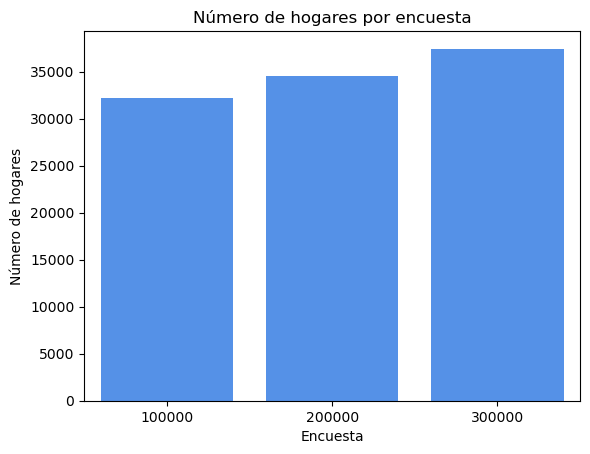

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=datos, x='survey_id', color='#3D8DFF')
plt.title('Número de hogares por encuesta')
plt.xlabel('Encuesta')
plt.ylabel('Número de hogares')
plt.show()


In [32]:
variables = [
    'survey_id', 'cons_ppp17', 'utl_exp_ppp17', 'male',
    'hsize', 'age', 'employed', 'educ_max', 'urban',
    'owner', 'water', 'elect'
]

datos_limpios = datos[variables].dropna().copy()
print(datos_limpios.shape)
print(datos_limpios.isna().sum())


(103994, 12)
survey_id        0
cons_ppp17       0
utl_exp_ppp17    0
male             0
hsize            0
age              0
employed         0
educ_max         0
urban            0
owner            0
water            0
elect            0
dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

muestra, _ = train_test_split(
    datos_limpios, train_size=1200,
    stratify=datos_limpios['survey_id'],
    random_state=20260807
)
muestra = muestra.reset_index(drop=True)
print(muestra['survey_id'].value_counts().sort_index())


survey_id
100000    371
200000    398
300000    431
Name: count, dtype: int64


In [34]:
muestra['educ_max'].value_counts()

educ_max
Complete Tertiary Education       336
Complete Secondary Education      294
Incomplete Tertiary Education     144
Incomplete Primary Education      141
Incomplete Secondary Education    128
Complete Primary Education        113
Never attended                     44
Name: count, dtype: int64

In [36]:
muestra.groupby("educ_max")["cons_ppp17"].agg({"mean", "median", "std"})

,median,mean,std
educ_max,,,
Complete Primary Education,5.867203,6.945103,5.151911
Complete Secondary Education,8.238339,11.259673,10.509375
Complete Tertiary Education,14.634035,18.860051,13.308195
Incomplete Primary Education,6.140496,7.518864,6.044306
Incomplete Secondary Education,5.996809,8.169010,5.085714
Incomplete Tertiary Education,10.750985,12.659763,9.089053
Never attended,4.987605,6.692941,4.126421


In [37]:
niveles_terciarios = [
    'Incomplete Tertiary Education',
    'Complete Tertiary Education'
]

muestra['educacion_terciaria'] = np.where(
    muestra['educ_max'].isin(niveles_terciarios), 'Sí', 'No'
)


In [38]:
muestra['educacion_terciaria'].value_counts()

educacion_terciaria
No    720
Sí    480
Name: count, dtype: int64

In [39]:
x = muestra['cons_ppp17']
n = x.size
k = int(np.ceil(1 + 3.322 * np.log10(n)))

clase = pd.cut(x, bins=k, include_lowest=True)
tdf = clase.value_counts(sort=False).rename('fi').to_frame()
tdf['Fi'] = tdf['fi'].cumsum()
tdf['hi'] = tdf['fi'] / n
tdf['Hi'] = tdf['hi'].cumsum()
tdf['xi'] = [intervalo.mid for intervalo in tdf.index]
tdf['fi_xi'] = tdf['fi'] * tdf['xi']
print(tdf)


                   fi    Fi        hi        Hi       xi      fi_xi
cons_ppp17                                                         
(1.499, 8.561]    567   567  0.472500  0.472500   5.0300  2852.0100
(8.561, 15.538]   364   931  0.303333  0.775833  12.0495  4386.0180
(15.538, 22.515]  137  1068  0.114167  0.890000  19.0265  2606.6305
(22.515, 29.493]   57  1125  0.047500  0.937500  26.0040  1482.2280
(29.493, 36.47]    26  1151  0.021667  0.959167  32.9815   857.5190
(36.47, 43.447]    15  1166  0.012500  0.971667  39.9585   599.3775
(43.447, 50.425]   12  1178  0.010000  0.981667  46.9360   563.2320
(50.425, 57.402]   12  1190  0.010000  0.991667  53.9135   646.9620
(57.402, 64.379]    2  1192  0.001667  0.993333  60.8905   121.7810
(64.379, 71.357]    5  1197  0.004167  0.997500  67.8680   339.3400
(71.357, 78.334]    0  1197  0.000000  0.997500  74.8455     0.0000
(78.334, 85.311]    3  1200  0.002500  1.000000  81.8225   245.4675


In [40]:
muestra["cons_ppp17"].mean()

np.float64(12.212838219250001)

In [13]:
tdf['prom']=tdf['xi']*tdf['fi']
tdf['prom'].sum()/1200

np.float64(12.250471250000002)

In [15]:
media_directa = x.mean()
print( media_directa)


12.212838219250001


In [16]:
resumen = x.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
moda = x.mode().tolist()
varianza = x.var(ddof=1)
desviacion = x.std(ddof=1)
cv = 100 * desviacion / x.mean()

print(resumen)
print('Moda:', moda)
print('Varianza:', varianza)
print('Desviación estándar:', desviacion)
print('Coeficiente de variación:', cv)


count    1200.000000
mean       12.212838
std        10.822251
min         1.583544
10%         3.810167
25%         5.522504
50%         9.052097
75%        14.646500
90%        23.627933
max        85.311226
Name: cons_ppp17, dtype: float64
Moda: [1.5835439, 1.8091391, 1.8714646, 1.8919085, 1.9284787, 2.0969, 2.0980699, 2.1269536, 2.1292369, 2.1313217, 2.1404257, 2.1684153, 2.1891983, 2.1956465, 2.208977, 2.2473156, 2.3254063, 2.3270805, 2.3283474, 2.3299572, 2.3491318, 2.3939915, 2.4580562, 2.4701214, 2.4814963, 2.5189555, 2.5219805, 2.5226874, 2.5360332, 2.5617146, 2.5857632, 2.6218259, 2.6310799, 2.6320951, 2.6580443, 2.666383, 2.6771753, 2.7048745, 2.7459097, 2.768662, 2.7885747, 2.8009324, 2.8120391, 2.81411, 2.8270113, 2.8275747, 2.8331444, 2.8346469, 2.861551, 2.8930616, 2.9256511, 2.9471292, 2.9621842, 3.019995, 3.0448763, 3.050761, 3.0531137, 3.058964, 3.0780165, 3.0866413, 3.0869389, 3.1015897, 3.1380782, 3.1481287, 3.175652, 3.1822939, 3.1946013, 3.1966028, 3.2066736, 3.22

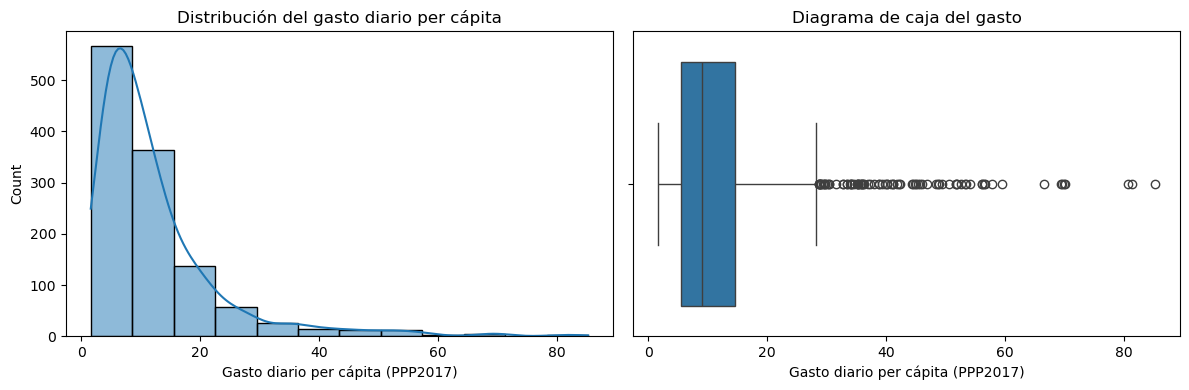

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=muestra, x='cons_ppp17', bins=k, kde=True, ax=ax[0])
ax[0].set_title('Distribución del gasto diario per cápita')
ax[0].set_xlabel('Gasto diario per cápita (PPP2017)')

sns.boxplot(data=muestra, x='cons_ppp17', ax=ax[1])
ax[1].set_title('Diagrama de caja del gasto')
ax[1].set_xlabel('Gasto diario per cápita (PPP2017)')
plt.tight_layout(); plt.show()


In [18]:
comparacion = muestra.groupby('educacion_terciaria').agg(
    n=('cons_ppp17', 'size'),
    media=('cons_ppp17', 'mean'),
    mediana=('cons_ppp17', 'median'),
    q1=('cons_ppp17', lambda s: s.quantile(0.25)),
    q3=('cons_ppp17', lambda s: s.quantile(0.75)),
    desviacion=('cons_ppp17', 'std')
)
comparacion['cv'] = 100 * comparacion['desviacion'] / comparacion['media']
print(comparacion.round(3))


                       n   media  mediana     q1      q3  desviacion      cv
educacion_terciaria                                                         
No                   720   9.021    6.779  4.517  10.677       8.092  89.693
Sí                   480  17.000   12.870  9.117  20.492      12.515  73.616


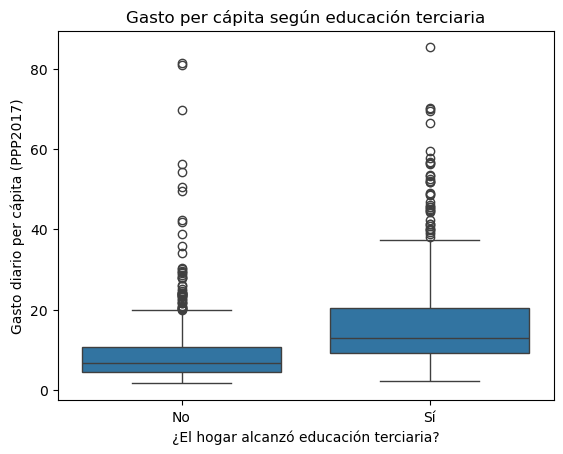

In [19]:
sns.boxplot(data=muestra, x='educacion_terciaria', y='cons_ppp17')
plt.title('Gasto per cápita según educación terciaria')
plt.xlabel('¿El hogar alcanzó educación terciaria?')
plt.ylabel('Gasto diario per cápita (PPP2017)')
plt.show()


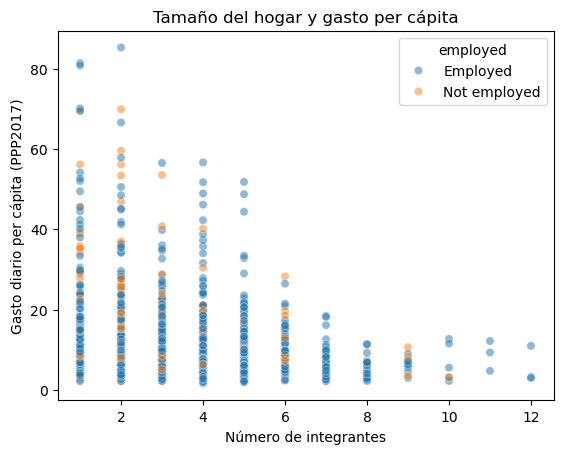

In [20]:
sns.scatterplot(
    data=muestra, x='hsize', y='cons_ppp17',
    hue='employed', alpha=0.5
)
plt.title('Tamaño del hogar y gasto per cápita')
plt.xlabel('Número de integrantes')
plt.ylabel('Gasto diario per cápita (PPP2017)')
plt.show()


C:\Users\DELL\miniconda3\envs\airgeo\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


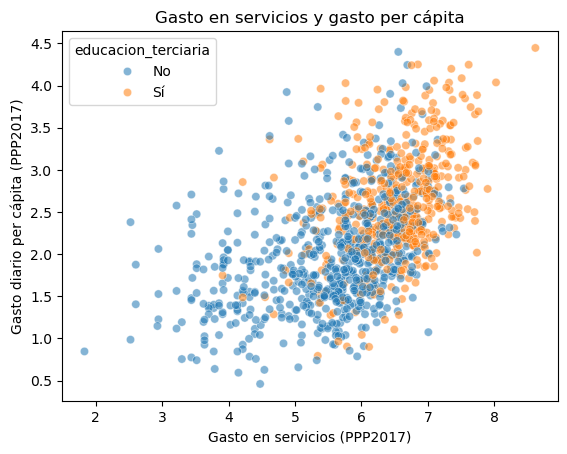

In [24]:
sns.scatterplot(
    data=muestra, x=np.log(muestra['utl_exp_ppp17']), y=np.log(muestra['cons_ppp17']),
    hue='educacion_terciaria', alpha=0.55
)
plt.title('Gasto en servicios y gasto per cápita')
plt.xlabel('Gasto en servicios (PPP2017)')
plt.ylabel('Gasto diario per cápita (PPP2017)')
plt.show()


## Visualización de Datos Adicionales (Pastel, Barra y Dispersión)

En esta sección se presentan gráficos adicionales para el análisis descriptivo de la muestra de hogares:
1. **Gráfico de Pastel**: Distribución proporcional de hogares según zona (Urbana vs Rural).
2. **Gráfico de Barras**: Consumo promedio diario per cápita según el nivel educativo máximo alcanzado.
3. **Gráfico de Dispersión**: Relación bidimensional y comparación entre el gasto en servicios públicos y el gasto diario per cápita (usando escala logarítmica).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar el estilo visual de seaborn para un acabado limpio y profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.facecolor'] = '#ffffff'
plt.rcParams['axes.facecolor'] = '#ffffff'

# 1. Gráfico de Pastel: Distribución de hogares por zona (Urban vs Rural)
plt.figure(figsize=(7, 7))
zona_counts = muestra['urban'].value_counts()
colors_pie = ['#3D8DFF', '#FF6B6B']  # Azul moderno y Coral suave

plt.pie(
    zona_counts, 
    labels=[f"{idx}\n({val:,} hogares)" for idx, val in zip(zona_counts.index, zona_counts.values)],
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_pie,
    wedgeprops={'edgecolor': '#ffffff', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 11, 'weight': 'normal'}
)
plt.title('Distribución de Hogares por Zona (Urbana vs Rural)\nen la Muestra', fontsize=14, pad=20, weight='bold', color='#333333')
plt.tight_layout()
plt.show()

# 2. Gráfico de Barras: Consumo diario promedio por nivel educativo
plt.figure(figsize=(10, 6))
bar_data = muestra.groupby('educ_max')['cons_ppp17'].mean().sort_values(ascending=True)

# Crear paleta degradada
colors_bar = sns.color_palette("Blues_d", len(bar_data))

sns.barplot(
    x=bar_data.values, 
    y=bar_data.index, 
    palette=colors_bar,
    hue=bar_data.index,
    legend=False,
    edgecolor='#cfcfcf',
    linewidth=0.8
)
plt.title('Gasto Diario Per Cápita Promedio por Nivel Educativo Máximo', fontsize=14, pad=15, weight='bold', color='#333333')
plt.xlabel('Gasto Diario Per Cápita Promedio (PPP2017)', fontsize=11, labelpad=10)
plt.ylabel('Nivel Educativo Máximo', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

# 3. Gráfico de Dispersión: Relación entre gasto en servicios y consumo per cápita
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=muestra, 
    x=np.log(muestra['utl_exp_ppp17'] + 1),  # Evitar log(0)
    y=np.log(muestra['cons_ppp17'] + 1),
    hue='educacion_terciaria', 
    palette={'Sí': '#FF6B6B', 'No': '#3D8DFF'},
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)
plt.title('Gasto en Servicios Públicos vs Gasto Per Cápita (Escala Logarítmica)', fontsize=14, pad=15, weight='bold', color='#333333')
plt.xlabel('Logaritmo del Gasto en Servicios (PPP2017 + 1)', fontsize=11, labelpad=10)
plt.ylabel('Logaritmo del Gasto Diario Per Cápita (PPP2017 + 1)', fontsize=11, labelpad=10)
plt.legend(title='¿Alcanzó educación terciaria?', title_fontsize=10, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()